# Introdução à Econometria - Resolução das Listas 1 a 5

Este notebook reorganiza o material original e apresenta a resolução das listas de exercícios da disciplina **Introdução à Econometria**. As listas combinam exercícios teóricos, exercícios numéricos e aplicações adaptadas de Wooldridge, *Introdução à Econometria: uma Abordagem Moderna*.

Quando a questão depende de uma base clássica do Wooldridge, o notebook tenta carregar a base pela biblioteca `wooldridge` em Python. Quando a questão traz apenas uma regressão já estimada no enunciado ou uma base específica da disciplina que não foi anexada, a solução usa os valores impressos no próprio enunciado e deixa o código preparado para replicação caso o arquivo seja colocado na pasta `data/manual`.

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    from statsmodels.stats.diagnostic import het_white, het_breuschpagan
except ImportError:
    sm = None
    smf = None
    het_white = None
    het_breuschpagan = None
    print("Instale statsmodels para executar as regressões: pip install statsmodels")

try:
    import wooldridge as woo
except ImportError:
    woo = None # Ensure woo is None if initial import fails
    print("Biblioteca wooldridge não encontrada. Tentando instalar...")
    try:
        !pip install wooldridge
        import wooldridge as woo # Re-import wooldridge after successful installation
        print("wooldridge instalado e importado com sucesso.")
    except Exception as e:
        woo = None
        print(f"Erro ao instalar ou reimportar wooldridge: {e}")


def carregar_wooldridge(nome):
    """Carrega uma base do pacote Python wooldridge, quando disponível."""
    if woo is None:
        raise ImportError("A biblioteca wooldridge não está disponível. Por favor, verifique a instalação.")
    return woo.data(nome)


def add_const(x):
    if sm is None:
        raise ImportError("statsmodels é necessário para esta célula")
    return sm.add_constant(x, has_constant='add')

pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

from pathlib import Path
FIG_DIR = Path('outputs/figures/notebook')
FIG_DIR.mkdir(parents=True, exist_ok=True)


def salvar_figura(nome):
    """Salva a figura corrente em PNG e PDF dentro de outputs/figures/notebook."""
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{nome}.png", dpi=300, bbox_inches='tight')
    plt.savefig(FIG_DIR / f"{nome}.pdf", bbox_inches='tight')


### Lista 1 - Estatística básica, esperança condicional e regressão simples

A primeira lista revisa conceitos fundamentais: tipos de dados, média e mediana, esperança condicional, covariância, propriedades algébricas das somas de desvios, regressão linear simples por MQO, interpretação de coeficientes, mudança de escala e $R^2$.

## Questão 1 - Despesas mensais com habitação

Os dados são de **corte transversal**, pois representam diferentes famílias observadas em um mesmo período. Não são série temporal, porque não acompanham uma mesma unidade ao longo do tempo, e não são painel, porque não combinam dimensão individual e temporal.

Para a amostra
\begin{equation}
(300,440,350,1100,640,480,450,700,670,530),
\end{equation}
a média e a mediana são calculadas por
\begin{equation}
\bar{x}=\frac{1}{n}\sum_{i=1}^n x_i,
\qquad
\operatorname{mediana}=\frac{x_{(5)}+x_{(6)}}{2},
\end{equation}
pois há dez observações.

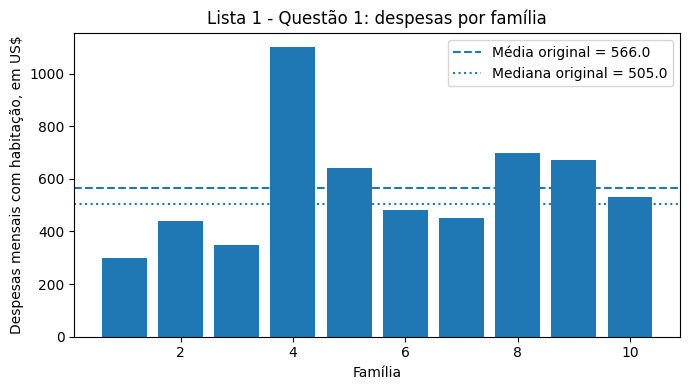

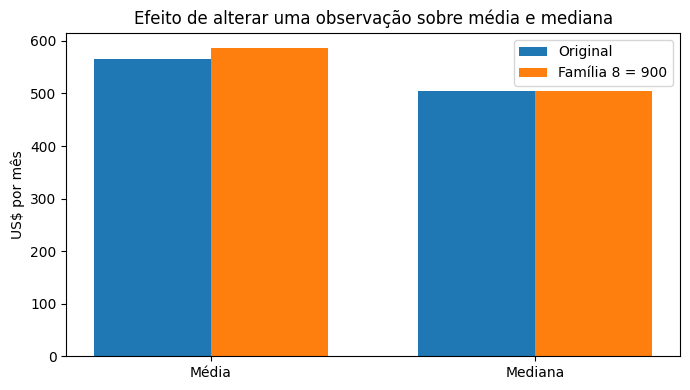

In [ ]:
despesas = np.array([300, 440, 350, 1100, 640, 480, 450, 700, 670, 530], dtype=float)
media = despesas.mean()
mediana = np.median(despesas)

# Se a unidade for centenas de dólares, basta dividir todos os valores por 100.
media_centenas = media / 100
mediana_centenas = mediana / 100

# Alteração da família 8 de 700 para 900 dólares.
despesas_nova = despesas.copy()
despesas_nova[7] = 900
media_nova = despesas_nova.mean()
mediana_nova = np.median(despesas_nova)

pd.DataFrame({
    'medida': ['média original', 'mediana original', 'média em centenas', 'mediana em centenas', 'nova média', 'nova mediana'],
    'valor': [media, mediana, media_centenas, mediana_centenas, media_nova, mediana_nova]
})

# Gráfico ilustrativo: distribuição das despesas e mudança da família 8
plt.figure(figsize=(7, 4))
plt.bar(np.arange(1, len(despesas) + 1), despesas)
plt.axhline(media, linestyle='--', label=f'Média original = {media:.1f}')
plt.axhline(mediana, linestyle=':', label=f'Mediana original = {mediana:.1f}')
plt.xlabel('Família')
plt.ylabel('Despesas mensais com habitação, em US$')
plt.title('Lista 1 - Questão 1: despesas por família')
plt.legend()
salvar_figura('lista01_q01_despesas_habitacao')
plt.show()

plt.figure(figsize=(7, 4))
pos = np.arange(2)
plt.bar(pos - 0.18, [media, mediana], width=0.36, label='Original')
plt.bar(pos + 0.18, [media_nova, mediana_nova], width=0.36, label='Família 8 = 900')
plt.xticks(pos, ['Média', 'Mediana'])
plt.ylabel('US$ por mês')
plt.title('Efeito de alterar uma observação sobre média e mediana')
plt.legend()
salvar_figura('lista01_q01_media_mediana_comparacao')
plt.show()


Logo, a média original é $566$ dólares e a mediana é $505$ dólares. Em centenas de dólares, esses valores passam a $5{,}66$ e $5{,}05$. Ao substituir a despesa da família 8 por $900$, a média sobe para $586$, enquanto a mediana permanece igual a $505$, pois os dois valores centrais continuam sendo $480$ e $530$.

## Questão 2 - Nota no vestibular como variável aleatória

A nota de um aluno em um vestibular pode ser tratada como variável aleatória porque, antes de sua realização, há incerteza sobre o resultado. Essa incerteza decorre de fatores como domínio efetivo do conteúdo, dificuldade da prova, condições de saúde, tempo de prova, ansiedade e até erros de medida. Assim, a nota possui uma distribuição de probabilidade, ainda que depois de observada assuma um valor fixo.

## Questão 3 - Esperança condicional entre IRA e SAT

A esperança condicional é
\begin{equation}
\mathbb{E}(IRA\mid SAT)=0{,}70+0{,}002SAT.
\end{equation}
Para $SAT=800$ e $SAT=1400$:

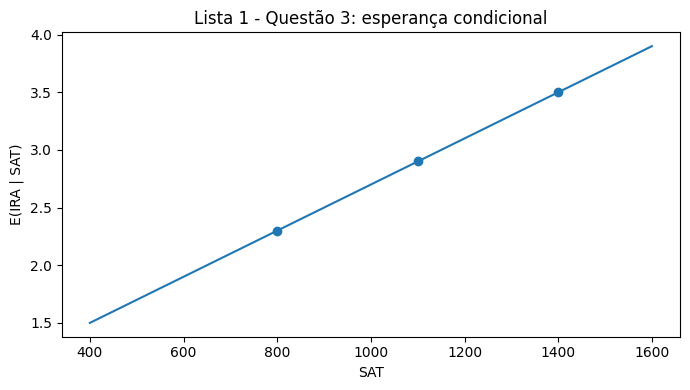

In [ ]:
def E_ira_sat(sat):
    return 0.70 + 0.002 * sat

resultados_q3 = pd.DataFrame({
    'SAT': [800, 1400, 1100],
    'E(IRA|SAT)': [E_ira_sat(800), E_ira_sat(1400), E_ira_sat(1100)]
})
resultados_q3

# Gráfico ilustrativo: função de esperança condicional E(IRA|SAT)
sat_grid = np.linspace(400, 1600, 200)
plt.figure(figsize=(7, 4))
plt.plot(sat_grid, E_ira_sat(sat_grid))
plt.scatter(resultados_q3['SAT'], resultados_q3['E(IRA|SAT)'])
plt.xlabel('SAT')
plt.ylabel('E(IRA | SAT)')
plt.title('Lista 1 - Questão 3: esperança condicional')
salvar_figura('lista01_q03_esperanca_condicional_ira_sat')
plt.show()


Portanto, $\mathbb{E}(IRA\mid SAT=800)=2{,}30$ e $\mathbb{E}(IRA\mid SAT=1400)=3{,}50$. A diferença é $1{,}20$ ponto de IRA. Pela Lei das Esperanças Iteradas,
\begin{equation}
\mathbb{E}(IRA)=\mathbb{E}[\mathbb{E}(IRA\mid SAT)]=0{,}70+0{,}002\mathbb{E}(SAT).
\end{equation}
Se $\mathbb{E}(SAT)=1100$, então $\mathbb{E}(IRA)=2{,}90$.

## Questão 4 - Covariância zero não implica média condicional constante

Sabendo que $\mathbb{E}[x]=\mathbb{E}[x^3]=0$ e que, na população, $y=x^2$, temos
\begin{equation}
\operatorname{Cov}(y,x)=\mathbb{E}(yx)-\mathbb{E}(y)\mathbb{E}(x)=\mathbb{E}(x^3)-\mathbb{E}(x^2)\mathbb{E}(x)=0- \mathbb{E}(x^2)\cdot 0=0.
\end{equation}
Entretanto, isso **não** implica $\mathbb{E}(y\mid x)=0$. Como $y=x^2$, segue que
\begin{equation}
\mathbb{E}(y\mid x)=x^2,
\end{equation}
ou seja, a média condicional de $y$ depende de $x^2$. O resultado mostra que covariância zero elimina apenas associação linear, não associação não linear.

## Questão 5 - Identidades algébricas de somas de desvios

Como $\sum_i(x_i-\bar{x})=0$ e $\sum_i(y_i-\bar{y})=0$, temos
\begin{equation}
\sum_{i=1}^n (x_i-\bar{x})(y_i-\bar{y})
=\sum_{i=1}^n y_i(x_i-\bar{x})
=\sum_{i=1}^n x_i(y_i-\bar{y})
\end{equation}
e também
\begin{equation}
\sum_{i=1}^n (x_i-\bar{x})(y_i-\bar{y})
=\sum_{i=1}^n x_i y_i - \frac{1}{n}\left(\sum_{i=1}^n x_i\right)\left(\sum_{i=1}^n y_i\right)
=\sum_{i=1}^n x_i y_i-n\bar{x}\bar{y}.
\end{equation}
Essas identidades são a base algébrica da fórmula da inclinação em MQO simples.

## Questão 6 - Função consumo e propensões marginal e média

A equação estimada é
\begin{equation}
\widehat{cons}=-124{,}84+0{,}853\,renda,
\qquad n=100,
\quad R^2=0{,}692.
\end{equation}
A propensão marginal a consumir é constante e igual a
\begin{equation}
\widehat{PMgC}=0{,}853.
\end{equation}
A propensão média estimada é
\begin{equation}
\widehat{PMeC}=\frac{\widehat{cons}}{renda}=\frac{-124{,}84}{renda}+0{,}853.
\end{equation}

Consumo previsto para renda = 30000: 25465.16


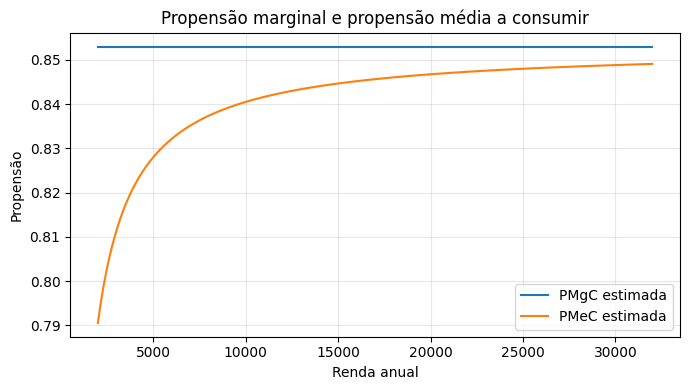

In [ ]:
renda = np.linspace(2000, 32000, 200)
pmgc = np.repeat(0.853, len(renda))
pmec = -124.84 / renda + 0.853
cons_30000 = -124.84 + 0.853 * 30000

print(f"Consumo previsto para renda = 30000: {cons_30000:.2f}")

plt.figure(figsize=(7,4))
plt.plot(renda, pmgc, label='PMgC estimada')
plt.plot(renda, pmec, label='PMeC estimada')
plt.xlabel('Renda anual')
plt.ylabel('Propensão')
plt.title('Propensão marginal e propensão média a consumir')
plt.legend()
plt.grid(True, alpha=0.3)
salvar_figura('lista01_q06_pmgc_pmec')
plt.show()


Para renda familiar de US\$ 30.000, o consumo previsto é US\$ 25.465,16. O intercepto negativo não tem interpretação econômica plausível em renda zero, especialmente porque zero está fora do intervalo amostral informado. A hipótese $\mathbb{E}(u\mid renda)=0$ pode ser pouco plausível se variáveis omitidas como riqueza, crédito, composição familiar, renda permanente e preferências forem correlacionadas com a renda corrente.

## Questão 7 - Regressão simples de GPA sobre ACT

O modelo é
\begin{equation}
GPA_i=\beta_0+\beta_1ACT_i+u_i.
\end{equation}
Com os oito dados da tabela, estimamos por MQO:

                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.577
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     8.199
Date:                Fri, 05 Jun 2026   Prob (F-statistic):             0.0287
Time:                        04:00:46   Log-Likelihood:                0.29842
No. Observations:                   8   AIC:                             3.403
Df Residuals:                       6   BIC:                             3.562
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5681      0.928      0.612      0.5

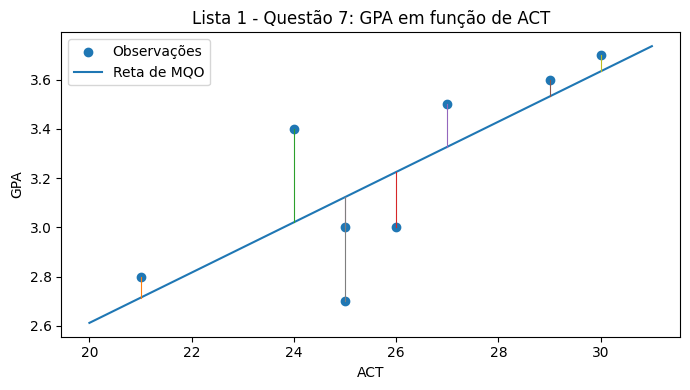

In [ ]:
gpa = np.array([2.8, 3.4, 3.0, 3.5, 3.6, 3.0, 2.7, 3.7])
act = np.array([21, 24, 26, 27, 29, 25, 25, 30])
df_gpa = pd.DataFrame({'GPA': gpa, 'ACT': act})

if sm is not None:
    mod_gpa = sm.OLS(df_gpa['GPA'], add_const(df_gpa['ACT'])).fit()
    print(mod_gpa.summary())
    print('Previsão para ACT=20:', mod_gpa.predict([1,20])[0])
    print('Soma dos resíduos:', mod_gpa.resid.sum())
    print('Variância estimada do erro:', mod_gpa.ssr / (len(df_gpa)-2))
    print('Matriz de variância-covariância dos coeficientes:')
    print(mod_gpa.cov_params())

    # Gráfico ilustrativo: dispersão, reta de MQO e resíduos
    act_grid = np.linspace(df_gpa['ACT'].min() - 1, df_gpa['ACT'].max() + 1, 100)
    y_grid = mod_gpa.params['const'] + mod_gpa.params['ACT'] * act_grid
    plt.figure(figsize=(7, 4))
    plt.scatter(df_gpa['ACT'], df_gpa['GPA'], label='Observações')
    plt.plot(act_grid, y_grid, label='Reta de MQO')
    for x_i, y_i, yhat_i in zip(df_gpa['ACT'], df_gpa['GPA'], mod_gpa.fittedvalues):
        plt.plot([x_i, x_i], [y_i, yhat_i], linewidth=0.8)
    plt.xlabel('ACT')
    plt.ylabel('GPA')
    plt.title('Lista 1 - Questão 7: GPA em função de ACT')
    plt.legend()
    salvar_figura('lista01_q07_gpa_act_mqo')
    plt.show()
else:
    print(df_gpa)


A reta estimada é aproximadamente
\begin{equation}
\widehat{GPA}=0{,}5681+0{,}1022ACT.
\end{equation}
Um aumento de cinco pontos em $ACT$ está associado a aumento previsto de $5\times 0{,}1022\approx 0{,}511$ ponto no GPA. O intercepto é a previsão para $ACT=0$, portanto não tem interpretação útil nesse contexto. Para $ACT=20$, a previsão é $2{,}612$. O $R^2\approx 0{,}577$ indica que cerca de 57,7% da variação amostral de GPA é explicada por ACT.

Se $GPAH=2GPA$, então os coeficientes estimados dobram. Se $ACTH=0{,}1ACT$, o intercepto permanece o mesmo e a inclinação é multiplicada por 10.

## Questão 8 - Erro com esperança condicional constante diferente de zero

Se
\begin{equation}
y=\beta_0+\beta_1x+u
\quad \text{e} \quad \mathbb{E}(u\mid x)=\alpha_0,
\end{equation}
com $\alpha_0$ constante, defina
\begin{equation}
v=u-\alpha_0,
\qquad
\beta_0^*=\beta_0+\alpha_0.
\end{equation}
Então
\begin{equation}
y=\beta_0^*+\beta_1x+v
\quad \text{e} \quad
\mathbb{E}(v\mid x)=\mathbb{E}(u\mid x)-\alpha_0=0.
\end{equation}
Logo, a hipótese de média condicional zero pode ser restaurada por uma reparametrização do intercepto.

## Questão 9 - Fertilidade e escolaridade

No modelo simples
\begin{equation}
filhos=\beta_0+\beta_1educ+u,
\end{equation}
variáveis omitidas potencialmente relevantes incluem idade da mulher, renda familiar, religião, acesso a métodos contraceptivos, local de residência, participação no mercado de trabalho, escolaridade do cônjuge e preferências por tamanho da família. Como várias dessas variáveis tendem a ser correlacionadas com escolaridade, a regressão simples dificilmente captura o efeito *ceteris paribus* de $educ$ sobre fertilidade.

## Questão 10 - Preço de casas e distância ao incinerador

A regressão estimada é
\begin{equation}
\log(preco)=9{,}40+0{,}312\log(dist),
\qquad n=135,
\quad R^2=0{,}162.
\end{equation}
Como o modelo é log-log, o coeficiente $0{,}312$ é uma elasticidade: um aumento de 1% na distância em relação ao incinerador está associado a aumento previsto de aproximadamente 0,312% no preço da casa. O sinal positivo é esperado, pois estar mais longe de uma fonte de incômodo ambiental tende a elevar o preço.

Contudo, se o incinerador foi instalado em área mais pobre, a qualidade do bairro é uma variável omitida positivamente correlacionada com distância e com preço. Nesse caso, o coeficiente de $\log(dist)$ tende a superestimar o efeito causal da distância. Outras variáveis omitidas possíveis são tamanho do lote, área construída, idade do imóvel, número de quartos, criminalidade, qualidade das escolas e renda média do bairro.

## Questão 11 - Peso ao nascer e consumo de cigarros

A equação estimada é
\begin{equation}
\widehat{pesonas}=119{,}77-0{,}514cigs,
\qquad n=1388.
\end{equation}
Para $cigs=0$, o peso previsto é $119{,}77$ onças. Para $cigs=20$, o peso previsto é
\begin{equation}
119{,}77-0{,}514(20)=109{,}49.
\end{equation}
A redução prevista é $10{,}28$ onças, ou aproximadamente $0{,}291$ kg. Para prever peso de 110 onças, resolvemos
\begin{equation}
110=119{,}77-0{,}514cigs.
\end{equation}

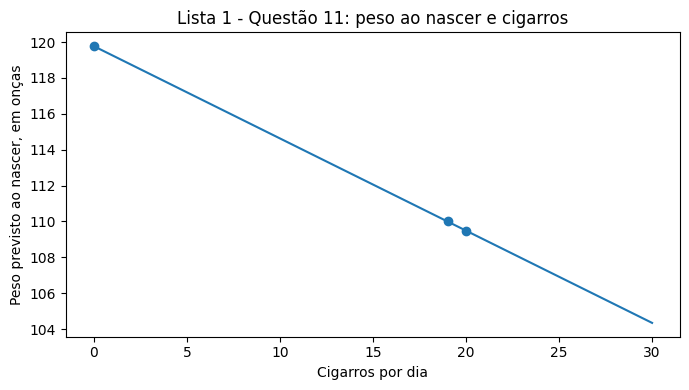

In [ ]:
peso_0 = 119.77
peso_20 = 119.77 - 0.514 * 20
reducao_kg = (peso_0 - peso_20) * 0.0283495
cigs_110 = (119.77 - 110) / 0.514
pd.DataFrame({
    'indicador': ['peso previsto se cigs=0', 'peso previsto se cigs=20', 'redução em kg', 'cigarros para peso=110 oz'],
    'valor': [peso_0, peso_20, reducao_kg, cigs_110]
})

# Gráfico ilustrativo: peso previsto ao nascer conforme cigarros/dia
cigs_grid = np.linspace(0, 30, 100)
peso_grid = 119.77 - 0.514 * cigs_grid
plt.figure(figsize=(7, 4))
plt.plot(cigs_grid, peso_grid)
plt.scatter([0, 20, cigs_110], [peso_0, peso_20, 110])
plt.xlabel('Cigarros por dia')
plt.ylabel('Peso previsto ao nascer, em onças')
plt.title('Lista 1 - Questão 11: peso ao nascer e cigarros')
salvar_figura('lista01_q11_peso_cigarros')
plt.show()


## Questão 12 - Condições de primeira ordem e Hessiana do MQO simples

A função objetivo é
\begin{equation}
f(\tilde\beta_0,\tilde\beta_1)=\sum_{i=1}^n (y_i-\tilde\beta_0-\tilde\beta_1x_i)^2.
\end{equation}
As condições de primeira ordem são
\begin{equation}
\frac{\partial f}{\partial \tilde\beta_0}=-2\sum_{i=1}^n(y_i-\tilde\beta_0-\tilde\beta_1x_i)=0,
\end{equation}
\begin{equation}
\frac{\partial f}{\partial \tilde\beta_1}=-2\sum_{i=1}^n x_i(y_i-\tilde\beta_0-\tilde\beta_1x_i)=0.
\end{equation}
Elas implicam
\begin{equation}
\hat\beta_1=\frac{\sum_i(x_i-\bar{x})(y_i-\bar{y})}{\sum_i(x_i-\bar{x})^2},
\qquad
\hat\beta_0=\bar{y}-\hat\beta_1\bar{x}.
\end{equation}
A Hessiana é
\begin{equation}
H=\begin{bmatrix}
2n & 2\sum_i x_i\\
2\sum_i x_i & 2\sum_i x_i^2
\end{bmatrix}.
\end{equation}
Os menores principais líderes são $2n>0$ e
\begin{equation}
|H|=4\left(n\sum_i x_i^2-\left(\sum_i x_i\right)^2\right)
=4n\sum_i(x_i-\bar{x})^2>0,
\end{equation}
desde que exista variação amostral em $x$. Portanto, a Hessiana é positiva definida.

## Questão 13 - Estimativa por momentos amostrais

Dados $\bar{y}=100$, $\bar{x}=40$, $\widehat{var}(y)=400$, $\widehat{var}(x)=100$ e $\widehat{cov}(x,y)=80$, temos
\begin{equation}
\hat\beta_1=\frac{\widehat{cov}(x,y)}{\widehat{var}(x)}=\frac{80}{100}=0{,}8,
\end{equation}
\begin{equation}
\hat\beta_0=\bar{y}-\hat\beta_1\bar{x}=100-0{,}8(40)=68.
\end{equation}
Logo,
\begin{equation}
\hat{y}=68+0{,}8x.
\end{equation}

## Questão 14 - Modelo ingênuo sem variável explicativa

No modelo
\begin{equation}
y_i=\beta_0+u_i,
\end{equation}
a previsão por MQO é sempre $\hat{y}_i=\bar{y}$. Assim,
\begin{equation}
SQE=\sum_i(\hat{y}_i-\bar{y})^2=0,
\end{equation}
logo $R^2=SQE/SQT=0$, desde que $SQT>0$.

## Questão 15 - Cálculo de $R^2$ por duas fórmulas

Para os dados $(x,y)=(1,3),(2,5),(3,6)$, estimamos $y=\beta_0+\beta_1x+u$.

const   1.6667
x       1.5000
dtype: float64
R2 por SQE/SQT: 0.9642857142857133
R2 por correlação ao quadrado: 0.9642857142857143


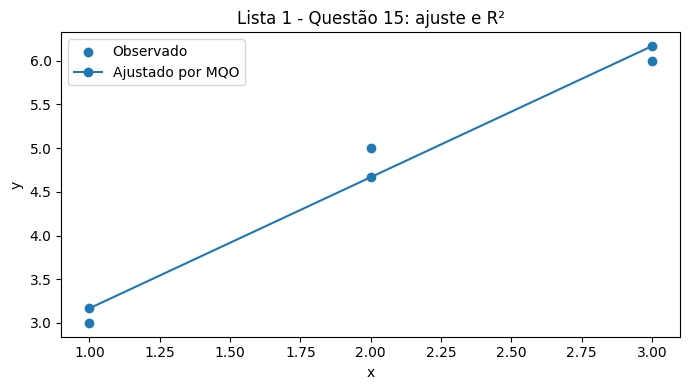

In [ ]:
df_q15 = pd.DataFrame({'x': [1,2,3], 'y': [3,5,6]})
if sm is not None:
    mod_q15 = sm.OLS(df_q15['y'], add_const(df_q15['x'])).fit()
    yhat = mod_q15.fittedvalues
    r2_sqe = ((yhat - df_q15['y'].mean())**2).sum() / ((df_q15['y'] - df_q15['y'].mean())**2).sum()
    r2_corr = np.corrcoef(df_q15['y'], yhat)[0,1]**2
    print(mod_q15.params)
    print('R2 por SQE/SQT:', r2_sqe)
    print('R2 por correlação ao quadrado:', r2_corr)

# Gráfico ilustrativo: valores observados e ajustados
    plt.figure(figsize=(7, 4))
    plt.scatter(df_q15['x'], df_q15['y'], label='Observado')
    plt.plot(df_q15['x'], yhat, marker='o', label='Ajustado por MQO')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Lista 1 - Questão 15: ajuste e R²')
    plt.legend()
    salvar_figura('lista01_q15_observado_ajustado')
    plt.show()


A reta estimada é
\begin{equation}
\hat{y}=1{,}6667+1{,}5x,
\end{equation}
e $R^2\approx 0{,}9643$. O mesmo valor é obtido por
\begin{equation}
R^2=\frac{SQE}{SQT}
\end{equation}
e por
\begin{equation}
R^2=\rho_{y,\hat{y}}^2,
\end{equation}
pois, no MQO com intercepto, a decomposição $SQT=SQE+SQR$ e a ortogonalidade entre valores ajustados e resíduos garantem a equivalência.

### Lista 2 - Regressão múltipla, interpretação ceteris paribus e viés por variável omitida

## Questão 1 - Educação, irmãos e escolaridade dos pais

A equação estimada é
\begin{equation}
\widehat{educ}=10{,}36-0{,}094irms+0{,}131educm+0{,}210educp.
\end{equation}
O coeficiente de $irms$ é negativo e esperado: mantendo fixa a escolaridade dos pais, mais irmãos podem diluir recursos familiares e reduzir a escolaridade prevista. Para reduzir a escolaridade prevista em um ano, seria necessário aumento de
\begin{equation}
\frac{1}{0{,}094}\approx 10{,}64
\end{equation}
irmãos, mantendo as demais variáveis constantes.

O coeficiente de $educm$ indica que um ano adicional de escolaridade da mãe aumenta a escolaridade prevista do indivíduo em $0{,}131$ ano, mantendo constantes $irms$ e $educp$.

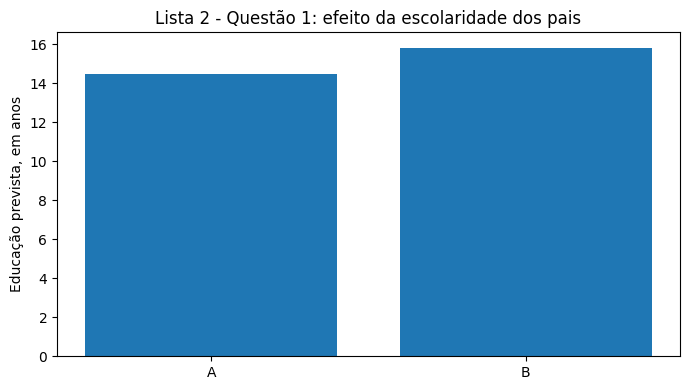

In [ ]:
def educ_hat(irms, educm, educp):
    return 10.36 - 0.094*irms + 0.131*educm + 0.210*educp

A = educ_hat(0, 12, 12)
B = educ_hat(0, 16, 16)
pd.DataFrame({'indivíduo': ['A', 'B', 'B - A'], 'educação prevista': [A, B, B-A]})

# Gráfico ilustrativo: comparação das previsões para A e B
plt.figure(figsize=(7, 4))
plt.bar(['A', 'B'], [A, B])
plt.ylabel('Educação prevista, em anos')
plt.title('Lista 2 - Questão 1: efeito da escolaridade dos pais')
salvar_figura('lista02_q01_educacao_prevista')
plt.show()


## Questão 2 - Parcelas de impostos e crescimento do emprego

O modelo é
\begin{equation}
cresc=\beta_0+\beta_1parcp+\beta_2parcr+\beta_3parcu+\text{outros fatores}.
\end{equation}
As quatro parcelas de impostos somam um:
\begin{equation}
parcp+parcr+parcu+parct=1.
\end{equation}
Logo, incluir todas as parcelas com intercepto causaria colinearidade perfeita. É necessário omitir uma categoria, aqui $parct$.

A interpretação de $\beta_1$ é: mantendo fixas as demais parcelas incluídas e os outros fatores, aumentar $parcp$ significa reduzir implicitamente a parcela omitida $parct$. Assim, $\beta_1$ mede o efeito de substituir a categoria omitida por impostos sobre propriedade. Um aumento de um ponto percentual em $parcp$ altera $cresc$ em $0{,}01\beta_1$ ponto percentual.

## Questões 3 e 4 - Viés por variável omitida

O modelo correto é
\begin{equation}
y_i=\beta_0+\beta_1x_{i1}+\beta_2x_{i2}+\beta_3x_{i3}+u_i,
\end{equation}
mas estima-se por engano
\begin{equation}
y_i=\tilde\beta_0+\tilde\beta_1x_{i1}+\tilde\beta_2x_{i2}+\tilde u_i.
\end{equation}
Considere a regressão auxiliar
\begin{equation}
x_{i3}=\tilde\delta_0+\tilde\delta_1x_{i1}+\tilde\delta_2x_{i2}+r_i.
\end{equation}
Então a relação amostral é
\begin{equation}
\tilde\beta_1=\hat\beta_1+\hat\beta_3\tilde\delta_1,
\end{equation}
e, em termos populacionais, o viés é
\begin{equation}
Bias(\tilde\beta_1)=\beta_3\delta_1.
\end{equation}

No exemplo de demanda por gasolina, se $x_1$ é o preço da gasolina, $x_2$ é o preço do álcool e $x_3$ é a renda per capita, então, admitindo gasolina como bem normal, $\beta_3>0$. Se regiões de renda maior também apresentam preços mais altos, $\delta_1>0$. Portanto, o viés é positivo: a estimativa de $\beta_1$ fica deslocada para cima, isto é, menos negativa do que o verdadeiro efeito-preço quando a demanda é decrescente no preço.

## Questão 5 - Regressão com dados de carros

A questão pede a estimação de
\begin{equation}
KPL_i=\beta_0+\beta_1VM_i+\beta_2HP_i+\beta_3PV_i+u_i.
\end{equation}
A interpretação de $\beta_1$ é o efeito parcial da velocidade máxima sobre quilômetros por litro, mantendo potência e peso constantes. O item seguinte aplica o Teorema de Frisch-Waugh-Lovell: se primeiro removemos de $VM$ a parte explicada por $HP$ e $PV$, e depois regredimos $KPL$ sobre esse resíduo, o coeficiente obtido é igual ao coeficiente de $VM$ na regressão múltipla completa.

Como o arquivo `cars.dta` específico da disciplina não foi anexado ao notebook, a célula abaixo procura `data/manual/cars_lista02.csv`. Se o arquivo for colocado nessa pasta, a replicação é executada automaticamente.

           KPL       VM       HP         PV      VOL
count 392.0000 392.0000 392.0000   392.0000 392.0000
mean   23.4459  15.5413 104.4694 2,977.5842 194.4120
std     7.8050   2.7589  38.4912   849.4026 104.6440
min     9.0000   8.0000  46.0000 1,613.0000  68.0000
25%    17.0000  13.7750  75.0000 2,225.2500 105.0000
50%    22.7500  15.5000  93.5000 2,803.5000 151.0000
75%    29.0000  17.0250 126.0000 3,614.7500 275.7500
max    46.6000  24.8000 230.0000 5,140.0000 455.0000
                            OLS Regression Results                            
Dep. Variable:                    KPL   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.704
Method:                 Least Squares   F-statistic:                     311.1
Date:                Fri, 05 Jun 2026   Prob (F-statistic):          7.48e-103
Time:                        04:11:02   Log-Likelihood:                -1121.0
No. Observations:                 392   AIC:     

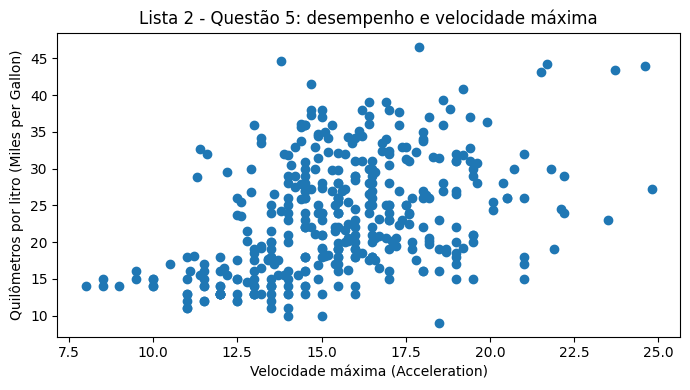

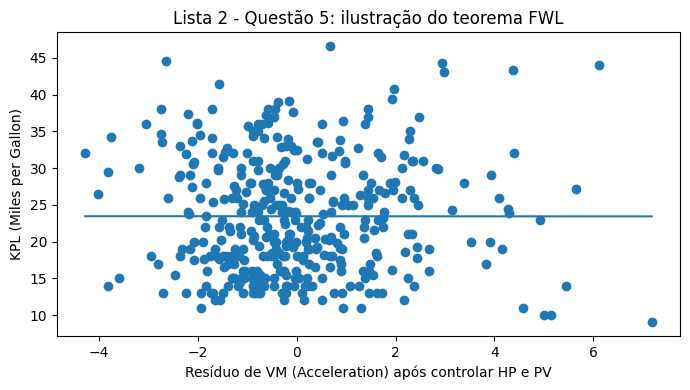

In [ ]:
from pathlib import Path
# Install the library via terminal as requested:
!pip install vega_datasets pandas
from vega_datasets import data
import pandas as pd
import numpy as np # Ensure numpy is imported for np.argsort

if smf is not None:
    try:
        cars = data.cars() # Modified to load from vega_datasets
        # Rename columns to match the expected names in the problem description
        cars = cars.rename(columns={
            'Miles_per_Gallon': 'KPL',
            'Acceleration': 'VM', # 'VM' (Velocidade Máxima) mapped to Acceleration as a proxy
            'Horsepower': 'HP',
            'Weight_in_lbs': 'PV', # 'PV' (Peso do Veículo) mapped to Weight_in_lbs
            'Displacement': 'VOL' # 'VOL' (Volume) mapped to Displacement as a proxy
        })

        # Drop rows with NaN values for the relevant columns to ensure consistent indexing
        cars = cars.dropna(subset=['KPL', 'VM', 'HP', 'PV', 'VOL'])

        print(cars[['KPL','VM','HP','PV','VOL']].describe())
        mod_full = smf.ols('KPL ~ VM + HP + PV', data=cars).fit()
        print(mod_full.summary())
        mod_vm = smf.ols('VM ~ HP + PV', data=cars).fit()
        cars['r_vm'] = mod_vm.resid
        mod_fwl = smf.ols('KPL ~ r_vm', data=cars).fit()
        print(mod_fwl.summary())

        # Gráficos ilustrativos, caso a base da disciplina seja fornecida
        plt.figure(figsize=(7, 4))
        plt.scatter(cars['VM'], cars['KPL'])
        plt.xlabel('Velocidade máxima (Acceleration)')
        plt.ylabel('Quilômetros por litro (Miles per Gallon)')
        plt.title('Lista 2 - Questão 5: desempenho e velocidade máxima')
        salvar_figura('lista02_q05_kpl_vm')
        plt.show()

        plt.figure(figsize=(7, 4))
        plt.scatter(cars['r_vm'], cars['KPL'])
        fitted_fwl = mod_fwl.fittedvalues
        # Ensure 'order' is calculated on the same data used for plotting
        order = np.argsort(cars['r_vm'])
        plt.plot(cars['r_vm'].iloc[order], fitted_fwl.iloc[order])
        plt.xlabel('Resíduo de VM (Acceleration) após controlar HP e PV')
        plt.ylabel('KPL (Miles per Gallon)')
        plt.title('Lista 2 - Questão 5: ilustração do teorema FWL')
        salvar_figura('lista02_q05_fwl')
        plt.show()
    except Exception as e:
        print('Não foi possível carregar/estimar a base cars do vega_datasets:', e)
else:
    print('Biblioteca statsmodels não disponível para esta seção. A solução teórica acima permanece válida.')

### Lista 3 - Testes de hipóteses, restrições lineares e aplicações com bases Wooldridge

## Questão 1 - Testes em regressão linear múltipla

No modelo
\begin{equation}
y=\beta_0+\beta_1x_1+\beta_2x_2+\beta_3x_3+\beta_4x_4+u,
\end{equation}
os testes são operacionalizados assim:

**(a)** Para $H_0:\beta_2=0$ contra $H_1:\beta_2\neq0$:
\begin{equation}
t=\frac{\hat\beta_2}{se(\hat\beta_2)},
\qquad gl=n-5.
\end{equation}

**(b)** Para $H_0:\beta_4=5$ contra $H_1:\beta_4\neq5$:
\begin{equation}
t=\frac{\hat\beta_4-5}{se(\hat\beta_4)},
\qquad gl=n-5.
\end{equation}

**(c)** Para $H_0:\beta_1=3\beta_4$ contra $H_1:\beta_1<3\beta_4$:
\begin{equation}
t=\frac{\hat\beta_1-3\hat\beta_4}{se(\hat\beta_1-3\hat\beta_4)},
\end{equation}
com
\begin{equation}
se(\hat\beta_1-3\hat\beta_4)=\sqrt{Var(\hat\beta_1)+9Var(\hat\beta_4)-6Cov(\hat\beta_1,\hat\beta_4)}.
\end{equation}

**(d)** Para $H_0:\beta_1=\beta_2=\beta_3=\beta_4=0$, usa-se teste $F$ com $q=4$ restrições:
\begin{equation}
F=\frac{(SQR_R-SQR_{UR})/4}{SQR_{UR}/(n-5)}.
\end{equation}

**(e)** Para $H_0:\beta_1=7\beta_3$, $\beta_2=0$ e $\beta_4=0$, há $q=3$ restrições e o teste também é
\begin{equation}
F=\frac{(SQR_R-SQR_{UR})/3}{SQR_{UR}/(n-5)}.
\end{equation}

## Questão 2 - Função Cobb-Douglas e retornos constantes de escala

A função de produção estocástica
\begin{equation}
y_i=\alpha x_{i1}^{\beta_1}x_{i2}^{\beta_2}e^{u_i}
\end{equation}
leva ao modelo log-linear
\begin{equation}
\log y_i=\beta_0+\beta_1\log x_{i1}+\beta_2\log x_{i2}+u_i,
\qquad \beta_0=\log\alpha.
\end{equation}
A hipótese de retornos constantes de escala é
\begin{equation}
H_0:\beta_1+\beta_2=1.
\end{equation}

Sem conhecer $Cov(\hat\beta_1,\hat\beta_2)$, uma forma operacional é reparametrizar:
\begin{equation}
\theta=\beta_1+\beta_2-1.
\end{equation}
Como $\beta_2=1-\beta_1+\theta$, temos
\begin{equation}
\log y_i-\log x_{i2}=\beta_0+\beta_1(\log x_{i1}-\log x_{i2})+\theta\log x_{i2}+u_i.
\end{equation}
Basta testar $H_0:\theta=0$ por teste $t$ com $gl=n-3$.

Se a covariância estiver disponível, usa-se
\begin{equation}
t=\frac{\hat\beta_1+\hat\beta_2-1}{\sqrt{Var(\hat\beta_1)+Var(\hat\beta_2)+2Cov(\hat\beta_1,\hat\beta_2)}}.
\end{equation}
Como há uma única restrição, o teste $F$ é equivalente a $t^2$.

## Questão 3 - Inclusão de variável irrelevante

Se o modelo populacional correto é
\begin{equation}
y=\beta_0+\beta_1x_1+u,
\end{equation}
mas se estima
\begin{equation}
y=\tilde\beta_0+\tilde\beta_1x_1+\tilde\beta_2x_2+v,
\end{equation}
e $x_2$ é de fato irrelevante e exógena, então $\tilde\beta_1$ permanece não viesado para $\beta_1$. Entretanto, sua variância aumenta quando $x_1$ é correlacionado com $x_2$:
\begin{equation}
Var(\tilde\beta_1)=\frac{\sigma^2}{SQT_{x_1}(1-R_1^2)}\geq \frac{\sigma^2}{SQT_{x_1}}.
\end{equation}
A igualdade ocorre apenas quando $R_1^2=0$, isto é, quando $x_1$ não é explicado por $x_2$.

## Questão 4 - CEOs: salário, vendas, ROE e ROS

O modelo é
\begin{equation}
\log(salary)=\beta_0+\beta_1\log(sales)+\beta_2roe+\beta_3ros+u.
\end{equation}
A hipótese de interesse é
\begin{equation}
H_0:\beta_3=0
\quad \text{contra} \quad
H_1:\beta_3>0.
\end{equation}
Pelos resultados do enunciado,
\begin{equation}
\widehat{\log(salary)}=4{,}3117+0{,}2803\log(sales)+0{,}0174roe+0{,}00024ros.
\end{equation}
Se $ros$ aumenta 50 pontos, então
\begin{equation}
\Delta \widehat{\log(salary)}=0{,}00024\times 50=0{,}012,
\end{equation}
ou aproximadamente 1,2% de aumento em salário. O teste individual é
\begin{equation}
t=\frac{0{,}00024}{0{,}00054}\approx0{,}44.
\end{equation}
Como esse valor é menor que o crítico unilateral a 10%, não rejeitamos $H_0$. Na prática, $ros$ tem efeito estimado pequeno e estatisticamente fraco.

                            OLS Regression Results                            
Dep. Variable:         np.log(salary)   R-squared:                       0.283
Model:                            OLS   Adj. R-squared:                  0.272
Method:                 Least Squares   F-statistic:                     26.93
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           1.00e-14
Time:                        04:06:38   Log-Likelihood:                -142.52
No. Observations:                 209   AIC:                             293.0
Df Residuals:                     205   BIC:                             306.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         4.3117      0.315     13.669

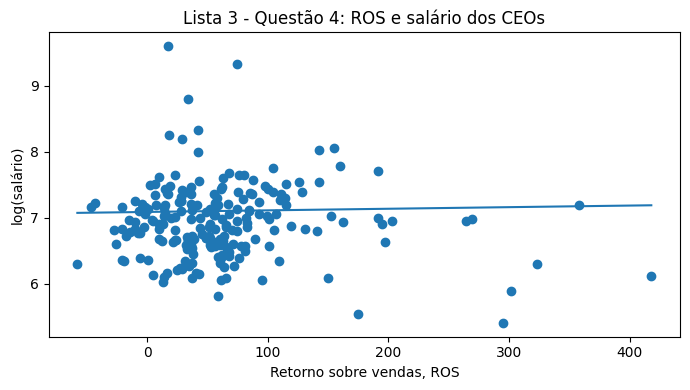

In [ ]:
# Replicação com a base ceosal1 de Wooldridge, se a biblioteca estiver instalada.
if woo is not None and smf is not None:
    try:
        ceosal1 = carregar_wooldridge('ceosal1')
        mod_ceo = smf.ols('np.log(salary) ~ np.log(sales) + roe + ros', data=ceosal1).fit()
        print(mod_ceo.summary())

        # Gráfico ilustrativo: relação visual entre ROS e log(salário)
        plt.figure(figsize=(7, 4))
        plt.scatter(ceosal1['ros'], np.log(ceosal1['salary']))
        ros_grid = np.linspace(ceosal1['ros'].min(), ceosal1['ros'].max(), 100)
        base_vals = ceosal1[['sales', 'roe']].mean()
        y_ros = (mod_ceo.params['Intercept']
                 + mod_ceo.params['np.log(sales)'] * np.log(base_vals['sales'])
                 + mod_ceo.params['roe'] * base_vals['roe']
                 + mod_ceo.params['ros'] * ros_grid)
        plt.plot(ros_grid, y_ros)
        plt.xlabel('Retorno sobre vendas, ROS')
        plt.ylabel('log(salário)')
        plt.title('Lista 3 - Questão 4: ROS e salário dos CEOs')
        salvar_figura('lista03_q04_ceosal1_ros_lsalary')
        plt.show()
    except Exception as e:
        print('Não foi possível carregar ceosal1:', e)


## Questão 5 - Quando estatísticas t deixam de seguir distribuição t?

A heterocedasticidade torna inválidas as estatísticas $t$ usuais baseadas em erros-padrão homocedásticos, embora os coeficientes de MQO possam permanecer não viesados sob exogeneidade. Correlação amostral de 0,95 entre regressores indica multicolinearidade forte, o que aumenta erros-padrão, mas não invalida a distribuição $t$ sob as hipóteses clássicas. Já a omissão de variável explicativa importante invalida a inferência quando a variável omitida é correlacionada com regressores incluídos, pois viola a exogeneidade.

## Questão 6 - Retornos de ações e previsibilidade

No primeiro modelo do enunciado, o teste conjunto tem $F(4,137)=1{,}41$ e $p=0{,}2347$. Assim, ao nível de 5%, não rejeitamos a hipótese de que as variáveis explicativas são conjuntamente insignificantes. Individualmente, nenhuma variável tem $p$-valor menor que 5%.

Na especificação alternativa com log de `netinc` e `salary`, o teste conjunto tem $F(4,137)=1{,}17$ e $p=0{,}3266$, também sem significância conjunta. A conclusão não se altera: a evidência de previsibilidade dos retornos é fraca. Não se usam logs de `dkr` e `eps` porque essas variáveis podem assumir valores zero ou negativos, o que tornaria o logaritmo indefinido.

                            OLS Regression Results                            
Dep. Variable:                    ret   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     1.408
Date:                Fri, 05 Jun 2026   Prob (F-statistic):              0.235
Time:                        04:06:47   Log-Likelihood:                -719.87
No. Observations:                 142   AIC:                             1450.
Df Residuals:                     137   BIC:                             1465.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -14.3702      6.894     -2.085      0.0

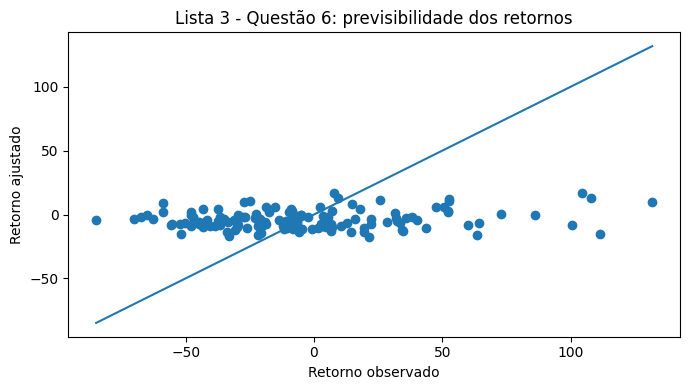

In [ ]:
# Replicação com a base return de Wooldridge, se disponível.
if woo is not None and smf is not None:
    try:
        ret = carregar_wooldridge('return')
        ret2 = ret.rename(columns={'return':'ret'}).copy()
        m1 = smf.ols('ret ~ dkr + eps + salary + netinc', data=ret2).fit()
        print(m1.summary())
        ret2['lnetinc'] = np.log(ret2['netinc'])
        ret2['lsalary'] = np.log(ret2['salary'])
        m2 = smf.ols('ret ~ dkr + eps + lsalary + lnetinc', data=ret2).fit()
        print(m2.summary())

        # Gráfico ilustrativo: retorno observado versus retorno ajustado
        plt.figure(figsize=(7, 4))
        plt.scatter(ret2['ret'], m2.fittedvalues)
        lims = [min(ret2['ret'].min(), m2.fittedvalues.min()), max(ret2['ret'].max(), m2.fittedvalues.max())]
        plt.plot(lims, lims)
        plt.xlabel('Retorno observado')
        plt.ylabel('Retorno ajustado')
        plt.title('Lista 3 - Questão 6: previsibilidade dos retornos')
        salvar_figura('lista03_q06_return_observado_ajustado')
        plt.show()
    except Exception as e:
        print('Não foi possível carregar/estimar a base return:', e)


## Questão 7 - Estatística $F$ em termos de $R^2$

A estatística geral é
\begin{equation}
F=\frac{(SQR_R-SQR_{UR})/q}{SQR_{UR}/(n-k-1)}.
\end{equation}
Como
\begin{equation}
SQR_R=(1-R_R^2)SQT,
\qquad
SQR_{UR}=(1-R_{UR}^2)SQT,
\end{equation}
substituindo na fórmula obtemos
\begin{equation}
F=\frac{(R_{UR}^2-R_R^2)/q}{(1-R_{UR}^2)/(n-k-1)}.
\end{equation}
Essa forma é útil quando os resultados disponíveis trazem apenas $R^2$ dos modelos restrito e irrestrito.

### Lista 4 - Formas funcionais, interações, produção e previsão

## Questão 1 - Ranking FIFA, termos quadráticos e dummies

A regressão estimada no enunciado é
\begin{equation}
\widehat{Y}=492{,}6+0{,}0107PIB-0{,}000000245PIB^2-0{,}4895(TEMP-14)^2+81{,}1SEDE+8587{,}5(LATINO\times POP).
\end{equation}
Com estatísticas $t$ em parênteses, e valores críticos $t_{70,5\%}=1{,}9944$ e $t_{70,10\%}=1{,}6669$, conclui-se: $PIB$ é significativo a 5\%; $PIB^2$ é significativo a 10\%, mas não a 5%; $(TEMP-14)^2$ é significativo aproximadamente a 5\%; `SEDE` é significativo a 10%, mas não a 5%; e $LATINO\times POP$ é significativo a 5%.

O efeito marginal de aumento de US\$ 100 no PIB per capita é
\begin{equation}
100\left(0{,}0107-2\cdot0{,}000000245PIB\right).
\end{equation}
O nível ótimo de PIB per capita, no sentido de maximizar a parcela quadrática, satisfaz
\begin{equation}
0{,}0107-2(0{,}000000245)PIB=0,
\end{equation}
logo
\begin{equation}
PIB^*=\frac{0{,}0107}{2\cdot0{,}000000245}\approx 21.837.
\end{equation}
Se o PIB passar a ser medido em milhares de dólares, os coeficientes de $PIB$ e $PIB^2$ passam a $10{,}7$ e $-0{,}245$, enquanto estatísticas $t$ e $R^2$ não mudam. A temperatura ótima é $14^\circ C$, pois o termo $-(TEMP-14)^2$ é máximo quando $TEMP=14$. O efeito da população é positivo apenas para países latino-americanos, pois aparece em interação com `LATINO`.

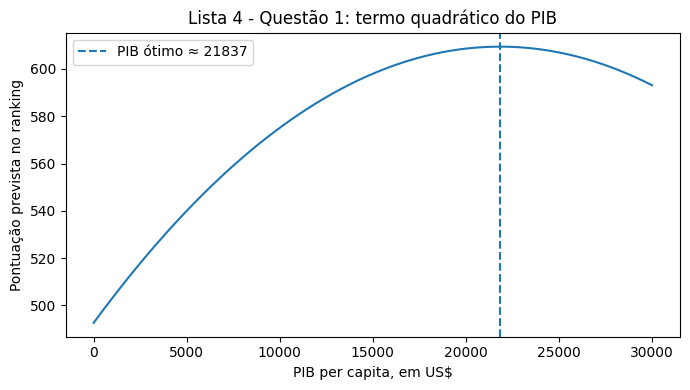

In [ ]:
pib_otimo = 0.0107/(2*0.000000245)
pib_otimo

# Gráfico ilustrativo: parcela quadrática do PIB, mantendo demais fatores fixos
pib_grid = np.linspace(0, 30000, 400)
y_pib = 492.6 + 0.0107 * pib_grid - 0.000000245 * pib_grid**2
plt.figure(figsize=(7, 4))
plt.plot(pib_grid, y_pib)
plt.axvline(pib_otimo, linestyle='--', label=f'PIB ótimo ≈ {pib_otimo:.0f}')
plt.xlabel('PIB per capita, em US$')
plt.ylabel('Pontuação prevista no ranking')
plt.title('Lista 4 - Questão 1: termo quadrático do PIB')
plt.legend()
salvar_figura('lista04_q01_pib_quadratico')
plt.show()


## Questão 2 - Modelo com interação

No modelo
\begin{equation}
y=\beta_0+\beta_1x_1+\beta_2x_2+\beta_3x_1x_2+u,
\end{equation}
as propensões marginais são
\begin{equation}
\frac{\partial y}{\partial x_1}=\beta_1+\beta_3x_2,
\qquad
\frac{\partial y}{\partial x_2}=\beta_2+\beta_3x_1.
\end{equation}
Para que a propensão marginal a consumir devido à renda não dependa da riqueza e a propensão marginal devida à riqueza não dependa da renda, é necessário e suficiente que
\begin{equation}
H_0:\beta_3=0.
\end{equation}
Portanto, testa-se o coeficiente da interação com um teste $t$ usual.

## Questão 3 - Função de produção log-log

A função estimada é
\begin{equation}
\widehat{\log Y}=1{,}1755+0{,}6022\log L+0{,}3756\log K,
\qquad n=27,
\quad R^2=0{,}94363.
\end{equation}
Os coeficientes são elasticidades. Um aumento de 1% em $L$ está associado a aumento previsto de 0,6022% em $Y$, e um aumento de 1% em $K$ a aumento previsto de 0,3756% em $Y$. Ambos são estatisticamente significativos pelos erros-padrão informados.

Se $Y$ passar de milhares para milhões de dólares, o intercepto diminui em $\log(1000)$:
\begin{equation}
1{,}1755-\log(1000)=-5{,}7323.
\end{equation}
Se $K$ passar de milhares para milhões de dólares, o intercepto aumenta em $0{,}3756\log(1000)$:
\begin{equation}
1{,}1755+0{,}3756\log(1000)=3{,}7695.
\end{equation}
O teste conjunto $H_0:\beta_L=\beta_K=0$ usa
\begin{equation}
F=\frac{R^2/2}{(1-R^2)/(27-2-1)}\approx 200{,}88,
\end{equation}
fortemente significativo.

Para aumento de 2% em $K$, a variação aproximada em $\log Y$ é $0{,}02\beta_K$. Usando $t_{24,0.975}\approx2{,}064$, o IC de 95% é
\begin{equation}
0{,}02(0{,}3756\pm2{,}064\cdot0{,}0851)=[0{,}0040,0{,}0110].
\end{equation}

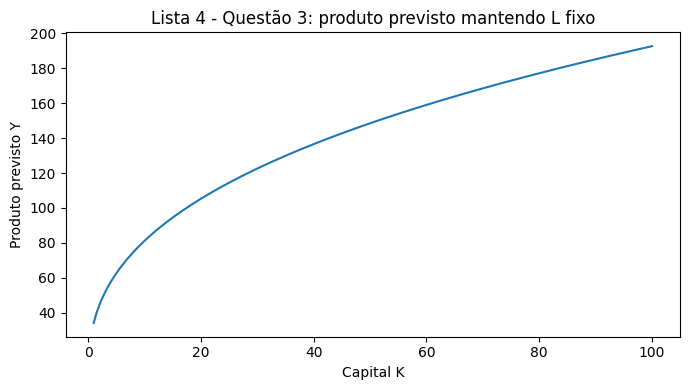

In [ ]:
R2 = 0.94363
n = 27
k = 2
F_prod = (R2/k)/((1-R2)/(n-k-1))
intercept_y_milhoes = 1.1755 - math.log(1000)
intercept_k_milhoes = 1.1755 + 0.3756 * math.log(1000)
ici = 0.02 * (0.3756 - 2.064*0.0851)
ics = 0.02 * (0.3756 + 2.064*0.0851)
pd.DataFrame({'indicador':['F conjunto','intercepto se Y em milhões','intercepto se K em milhões','IC inferior efeito 2% K','IC superior efeito 2% K'],
              'valor':[F_prod, intercept_y_milhoes, intercept_k_milhoes, ici, ics]})

# Gráfico ilustrativo: elasticidade do capital em uma função Cobb-Douglas
K_grid = np.linspace(1, 100, 200)
L_fix = 50
Y_grid = np.exp(1.1755) * (L_fix ** 0.6022) * (K_grid ** 0.3756)
plt.figure(figsize=(7, 4))
plt.plot(K_grid, Y_grid)
plt.xlabel('Capital K')
plt.ylabel('Produto previsto Y')
plt.title('Lista 4 - Questão 3: produto previsto mantendo L fixo')
salvar_figura('lista04_q03_cobb_douglas_capital')
plt.show()


## Questão 4 - Consumo de combustível, potência e peso

A regressão estimada é
\begin{equation}
\widehat{mpg}=43{,}998-0{,}022hp-0{,}006wght.
\end{equation}
Os sinais são economicamente plausíveis: maior potência e maior peso reduzem milhas por galão. Pelos coeficientes padronizados, o peso tem maior importância relativa em módulo do que a potência.

Para prever o desempenho de um carro com 240 hp e 3500 libras, a regressão foi reparametrizada como
\begin{equation}
mpg=\delta_1+\beta_1(hp-240)+\beta_2(wght-3500)+u.
\end{equation}
Nesse modelo, o intercepto $\delta_1$ é exatamente a previsão para $hp=240$ e $wght=3500$. Pelo enunciado,
\begin{equation}
\hat\delta_1=18{,}897,
\end{equation}
com intervalo de confiança de 95%
\begin{equation}
[18{,}168,19{,}626].
\end{equation}

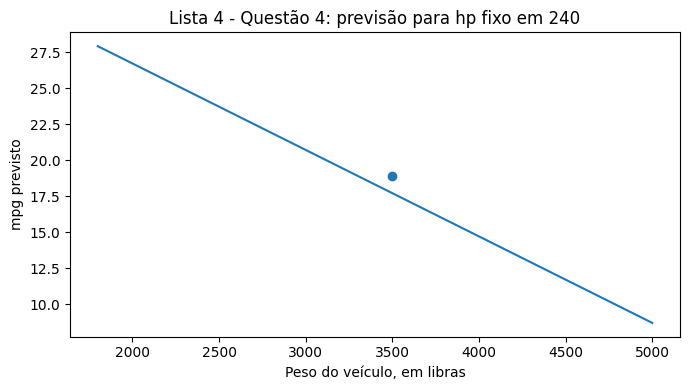

In [ ]:

# Gráfico ilustrativo: mpg previsto por peso, mantendo hp = 240
mpg_grid_wght = np.linspace(1800, 5000, 200)
mpg_pred_wght = 43.998 - 0.022 * 240 - 0.006 * mpg_grid_wght
plt.figure(figsize=(7, 4))
plt.plot(mpg_grid_wght, mpg_pred_wght)
plt.scatter([3500], [18.897])
plt.xlabel('Peso do veículo, em libras')
plt.ylabel('mpg previsto')
plt.title('Lista 4 - Questão 4: previsão para hp fixo em 240')
salvar_figura('lista04_q04_mpg_peso_hp240')
plt.show()


### Lista 5 - Variáveis binárias, heterocedasticidade, MQP e álgebra matricial do MQO

## Questão 1 - Dummy para posse de computador e interação

O modelo inicial é
\begin{equation}
nmgrad=\beta_0+\beta_1nmem+\beta_2tac+\beta_3tothrs+\beta_4estudh+u.
\end{equation}
Para permitir interceptos diferentes entre possuidores e não possuidores de computador, defina
\begin{equation}
PC_i=\begin{cases}
1,&\text{se possui computador},\\
0,&\text{caso contrário}.
\end{cases}
\end{equation}
O modelo fica
\begin{equation}
nmgrad=\beta_0+\delta_0PC+\beta_1nmem+\beta_2tac+\beta_3tothrs+\beta_4estudh+u.
\end{equation}
O grupo base é o dos não possuidores de PC.

Para permitir que a produtividade das horas de estudo também difira entre grupos:
\begin{equation}
nmgrad=\beta_0+\delta_0PC+\beta_1nmem+\beta_2tac+\beta_3tothrs+\beta_4estudh+\delta_1(PC\times estudh)+u.
\end{equation}
A hipótese de ausência de diferença entre grupos é
\begin{equation}
H_0:\delta_0=0 \quad \text{e} \quad \delta_1=0,
\end{equation}
testada por $F$ com duas restrições.

Se, em vez de $PC$, usa-se $semPC=1-PC$, a categoria base passa a ser a dos possuidores de PC. No modelo com interação,
\begin{equation}
\alpha_0=\beta_0+\delta_0,
\quad
\alpha_{semPC}=-\delta_0,
\quad
\alpha_{estudh}=\beta_4+\delta_1,
\quad
\alpha_{semPC\times estudh}=-\delta_1.
\end{equation}
Incluir simultaneamente intercepto, $PC$ e $semPC$ causa colinearidade perfeita, pois $PC+semPC=1$.

## Questão 2 - Pobreza municipal, regiões e interação com escolaridade

O modelo é
\begin{equation}
\begin{aligned}
pobreza={}&\beta_0+\delta_0no+\delta_1ne+\delta_2su+\delta_3co+\beta_1pibpc+\beta_2escol\\
&+\delta_4(escol\times no)+\delta_5(escol\times ne)+\delta_6(escol\times su)+\delta_7(escol\times co)+u.
\end{aligned}
\end{equation}
A região base é o Sudeste, pois as dummies de Norte, Nordeste, Sul e Centro-Oeste são incluídas e a dummy do Sudeste é omitida.

O efeito marginal de estar na região $r$, avaliado na média de escolaridade $\bar{escol}=3{,}14$, é
\begin{equation}
\delta_r+3{,}14\cdot\delta_{r,escol}.
\end{equation}
A diferença Nordeste-Sudeste para $pibpc=3{,}10$ e $escol=3{,}14$ é
\begin{equation}
\delta_1+3{,}14\delta_5.
\end{equation}
O efeito marginal de um ano de escolaridade é
\begin{equation}
\frac{\partial pobreza}{\partial escol}=\beta_2
\end{equation}
no Sudeste; $\beta_2+\delta_4$ no Norte; $\beta_2+\delta_5$ no Nordeste; $\beta_2+\delta_6$ no Sul; e $\beta_2+\delta_7$ no Centro-Oeste.

Como a base municipal não foi anexada, o pacote de replicação contém scripts que procuram o arquivo `data/manual/municipios_lista05.csv` e executam MQO, MQO robusto de White e teste de White quando o arquivo estiver disponível.

## Questão 3 - Detecção e correção de heterocedasticidade

Com os dez dados da tabela, estimamos
\begin{equation}
y_i=\beta_0+\beta_1x_i+u_i.
\end{equation}

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.264
Model:                            OLS   Adj. R-squared:                  0.173
Method:                 Least Squares   F-statistic:                     2.877
Date:                Fri, 05 Jun 2026   Prob (F-statistic):              0.128
Time:                        04:07:11   Log-Likelihood:                -86.365
No. Observations:                  10   AIC:                             176.7
Df Residuals:                       8   BIC:                             177.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        363.5255    833.912      0.436      0.6

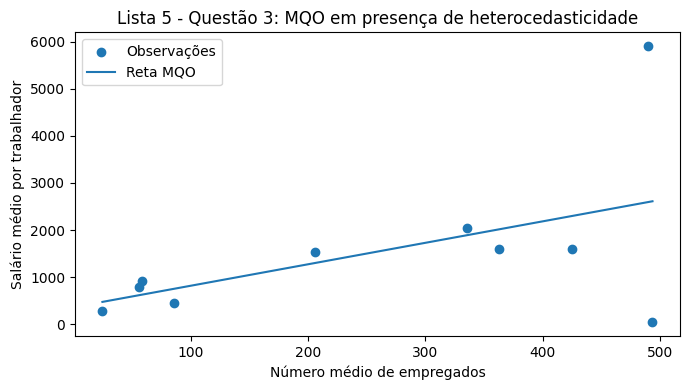

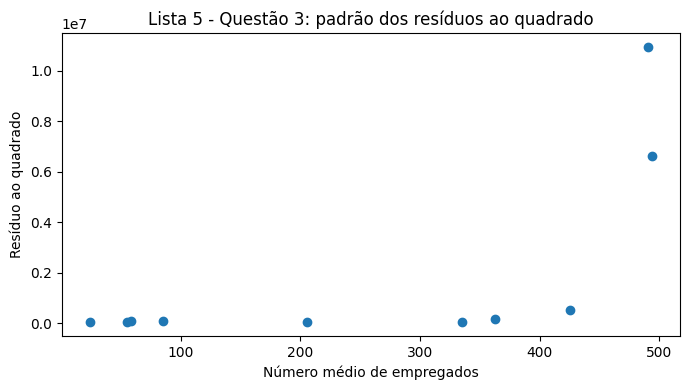

In [ ]:
df_hetero = pd.DataFrame({
    'empresa': np.arange(1, 11),
    'y': [459.6, 2048.9, 1587.2, 1540.1, 279.7, 794.2, 38.6, 1600.7, 923.3, 5905.3],
    'x': [85.0, 335.0, 425.1, 205.4, 24.3, 55.2, 493.7, 362.9, 58.5, 490.1]
})

if sm is not None:
    ols_hetero = sm.OLS(df_hetero['y'], add_const(df_hetero['x'])).fit()
    print(ols_hetero.summary())
    if het_white is not None:
        lm, lm_p, fstat, f_p = het_white(ols_hetero.resid, add_const(df_hetero['x']))
        print(f'Teste de White: LM={lm:.4f}, p-valor LM={lm_p:.4f}, F={fstat:.4f}, p-valor F={f_p:.4f}')
    rob_hetero = ols_hetero.get_robustcov_results(cov_type='HC1')
    print('Erros-padrão robustos HC1')
    print(rob_hetero.summary())
    wls_hetero = sm.WLS(df_hetero['y'], add_const(df_hetero['x']), weights=1/(df_hetero['x']**2)).fit()
    print('MQP/WLS com Var(u|x)=sigma^2 x^2')
    print(wls_hetero.summary())

# Gráficos ilustrativos: heterocedasticidade e correção por MQP
    x_grid = np.linspace(df_hetero['x'].min(), df_hetero['x'].max(), 200)
    y_grid = ols_hetero.params['const'] + ols_hetero.params['x'] * x_grid
    plt.figure(figsize=(7, 4))
    plt.scatter(df_hetero['x'], df_hetero['y'], label='Observações')
    plt.plot(x_grid, y_grid, label='Reta MQO')
    plt.xlabel('Número médio de empregados')
    plt.ylabel('Salário médio por trabalhador')
    plt.title('Lista 5 - Questão 3: MQO em presença de heterocedasticidade')
    plt.legend()
    salvar_figura('lista05_q03_hetero_scatter_mqo')
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.scatter(df_hetero['x'], ols_hetero.resid**2)
    plt.xlabel('Número médio de empregados')
    plt.ylabel('Resíduo ao quadrado')
    plt.title('Lista 5 - Questão 3: padrão dos resíduos ao quadrado')
    salvar_figura('lista05_q03_residuos_quadrados')
    plt.show()


A regressão MQO fornece aproximadamente
\begin{equation}
\hat y=363{,}53+4{,}553x.
\end{equation}
O teste de White rejeita homocedasticidade nos dados da tabela. Com erros-padrão robustos, os coeficientes não mudam, apenas a inferência. Se a forma correta é $Var(u_i\mid x_i)=\sigma^2x_i^2$, então MQP/WLS com pesos $1/x_i^2$ é preferível ao MQO robusto, pois além de corrigir a inferência, ganha eficiência sob a forma conhecida da heterocedasticidade.

## Questão 4 - Transformação por empregados e heterocedasticidade

A primeira regressão é
\begin{equation}
\widehat{salario}=7{,}5+0{,}009empreg,
\qquad R^2=0{,}90.
\end{equation}
A segunda é
\begin{equation}
\widehat{\frac{salario}{empreg}}=0{,}008+7{,}9empreg^{-1},
\qquad R^2=0{,}99.
\end{equation}
Se o modelo original é
\begin{equation}
salario=\beta_0+\beta_1empreg+u,
\end{equation}
dividir por $empreg$ gera
\begin{equation}
\frac{salario}{empreg}=\beta_1+\beta_0\frac{1}{empreg}+\frac{u}{empreg}.
\end{equation}
Logo, o intercepto da regressão transformada corresponde à inclinação do modelo original, e o coeficiente de $empreg^{-1}$ corresponde ao intercepto do modelo original, salvo diferenças de arredondamento. Essa transformação supõe heterocedasticidade do tipo
\begin{equation}
Var(u\mid empreg)=\sigma^2empreg^2.
\end{equation}
Os dois $R^2$ não são diretamente comparáveis, pois as variáveis dependentes são diferentes.

## Questão 5 - MQO com matriz de variância não escalar

Com
\begin{equation}
X=\begin{bmatrix}1\\1\\1\\1\\1\end{bmatrix},
\qquad
 y=\begin{bmatrix}0\\7\\5\\0\\0\end{bmatrix},
\end{equation}
a estimativa de MQO é
\begin{equation}
\hat\beta=(X'X)^{-1}X'y=\frac{1}{5}(12)=2{,}4.
\end{equation}
Como
\begin{equation}
E(ee'\mid X)=\begin{bmatrix}
1&0&0&0&0\\
0&3&0&0&0\\
0&0&4&0&0\\
0&0&0&6&0\\
0&0&0&0&8
\end{bmatrix},
\end{equation}
temos
\begin{equation}
Var(u_1\mid X)=1,
Var(u_2\mid X)=3,
Var(u_3\mid X)=4,
Var(u_4\mid X)=6,
Var(u_5\mid X)=8,
\end{equation}
e $Cov(u_i,u_j\mid X)=0$ para $i\neq j$.

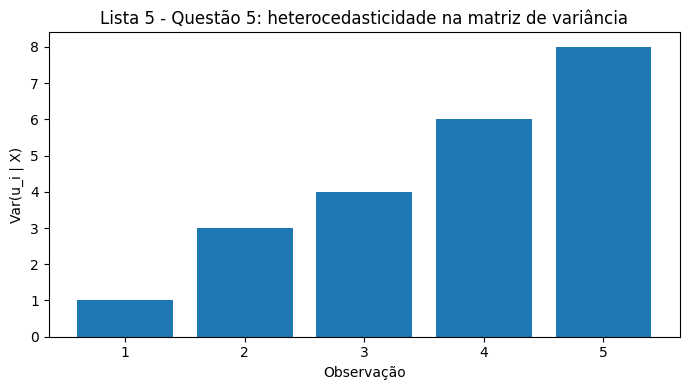

In [ ]:
X = np.ones((5,1))
y = np.array([0,7,5,0,0]).reshape(-1,1)
beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
beta_hat

# Gráfico ilustrativo: variâncias condicionais não constantes do erro
variancias = np.array([1, 3, 4, 6, 8])
plt.figure(figsize=(7, 4))
plt.bar(np.arange(1, 6), variancias)
plt.xlabel('Observação')
plt.ylabel('Var(u_i | X)')
plt.title('Lista 5 - Questão 5: heterocedasticidade na matriz de variância')
salvar_figura('lista05_q05_variancias_condicionais')
plt.show()


## Questão 6 - Matrizes dos modelos particulares

**Modelo 1:** $y_i=\beta_1+u_i$.
\begin{equation}
X=\mathbf{1}_n,
\qquad
X'X=n,
\qquad
X'y=\sum_{i=1}^n y_i.
\end{equation}
Portanto,
\begin{equation}
\hat\beta_1=\frac{1}{n}\sum_{i=1}^n y_i=\bar y.
\end{equation}

**Modelo 2:** $y_i=\beta_1+\beta_2x_{i2}+u_i$.
\begin{equation}
X'X=\begin{bmatrix}
n&\sum_i x_{i2}\\
\sum_i x_{i2}&\sum_i x_{i2}^2
\end{bmatrix},
\qquad
X'y=\begin{bmatrix}
\sum_i y_i\\
\sum_i x_{i2}y_i
\end{bmatrix}.
\end{equation}
Da inversão dessa matriz resulta
\begin{equation}
\hat\beta_2=\frac{n\sum_i x_{i2}y_i-\sum_i x_{i2}\sum_i y_i}{n\sum_i x_{i2}^2-(\sum_i x_{i2})^2}
=\frac{\sum_i(x_{i2}-\bar{x}_2)(y_i-\bar y)}{\sum_i(x_{i2}-\bar{x}_2)^2}.
\end{equation}

**Modelo 3:** $y_i=\beta_1x_{i1}+\beta_2x_{i2}+u_i$, sem intercepto.
\begin{equation}
X'X=\begin{bmatrix}
\sum_i x_{i1}^2&\sum_i x_{i1}x_{i2}\\
\sum_i x_{i1}x_{i2}&\sum_i x_{i2}^2
\end{bmatrix},
\qquad
X'y=\begin{bmatrix}
\sum_i x_{i1}y_i\\
\sum_i x_{i2}y_i
\end{bmatrix}.
\end{equation}